# Tennis Data

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from package import algorithm

current_path = os.getcwd()
data_path = current_path + '\\' + 'data' + '\\' + 'tennis' + '\\' 
image_path = current_path + '\\' + 'image'+ '\\' + 'tennis'+ '\\'

### Data Preprocessing

In [2]:
covariate = ['winner_age', 'loser_age']
df = combined_df = pd.DataFrame()
for file in os.listdir(data_path):
    if 'atp_matches' in file:
        tem = pd.read_csv(data_path+file,)
        tem = tem.drop(tem[tem['score'] == 'W/O'].index)
        tem = tem.dropna(subset=covariate)
        df = pd.concat([df, tem], ignore_index=True)
    else:
        pass

Select suitable matches and players <br>
<span style="font-size: smaller;">
We remove players whose competition times are less than 10 or who have never won.
</span> 

In [3]:
def delete_players(df,d_min):
    players = df[['winner_name','loser_name']]
    counts = pd.Series(players.values.ravel()).value_counts()
    ### d >= d_min
    remain_players = counts[counts>=d_min].index
    ### winner
    remain_players = remain_players[remain_players.isin(df['winner_name'])].tolist()
    n = len(remain_players)
    return remain_players,n
def delete_matches(df,remain_players):
    df = df[df[['winner_name','loser_name']].isin(remain_players).all(axis=1)]
    N = len(df)
    return df,N
def select(df,d_min=10):
    players = df[['winner_name','loser_name']]
    counts = pd.Series(players.values.ravel()).value_counts()
    all_players = counts.index.tolist()
    nn = len(all_players)
    NN = len(df)
    while True:
        print('-'*10)
        print(f'The number of matches: {NN}')
        print(f'The number of players: {nn}')
        remain_players,n = delete_players(df,d_min)
        df,N = delete_matches(df,remain_players)
        if NN == N and nn == n:
            break
        else:
            NN = N
            nn = n
    return df,n,N    
df,n,N = select(df,10)

----------
The number of matches: 145658
The number of players: 4603
----------
The number of matches: 138397
The number of players: 1991
----------
The number of matches: 137392
The number of players: 1856
----------
The number of matches: 137127
The number of players: 1825
----------
The number of matches: 137043
The number of players: 1815
----------
The number of matches: 136989
The number of players: 1809
----------
The number of matches: 136962
The number of players: 1806
----------
The number of matches: 136944
The number of players: 1804
----------
The number of matches: 136935
The number of players: 1803


In [4]:
df.to_csv(data_path+'tennis(preprocessed).csv',index=None)

### Data Analysis

In [5]:
# read data
df = pd.read_csv(data_path+'tennis(preprocessed).csv')

# players ID
players = df[['winner_name','loser_name']]
counts = pd.Series(players.values.ravel()).value_counts()
playerID = {value: index for index, value in enumerate(counts.index.tolist())}
n = len(playerID)
# matches
name_columns = ['winner_name','loser_name']
Matches = df[name_columns].replace(playerID)
T = np.array(Matches).tolist()
N = len(T)
# age
age_columns = ['winner_age','loser_age']
Age = np.array(df[age_columns])


C:\Users\13299\AppData\Local\Temp\ipykernel_8984\2717211070.py:2: DtypeWarning: Columns (8,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path+'tennis(preprocessed).csv')
C:\Users\13299\AppData\Local\Temp\ipykernel_8984\2717211070.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Matches = df[name_columns].replace(playerID)


In [6]:
# kernel
A = [25,30,35]
Lamb = [0.01, 0.03]
parameters = [(a,lamb) for a in A for lamb in Lamb]
gauss_kernel = lambda x,a,lamb: np.exp(-lamb*(x-a)**2)
gauss_kernel_set = lambda x: np.array([gauss_kernel(x,a,lamb) for (a,lamb) in parameters])
cov = [gauss_kernel_set(age).T for age in Age]

##### Model selection

BIC criteria

In [8]:
import itertools
from joblib import Parallel, delayed
# BIC
def get_BIC(T,cov,s,N,n):
    X = [x[:,s] for x in cov]
    d = len(s)
    u_plusDC,v_plusDC = algorithm.AM(T,X,n,d,E=1e-3,Eu=1e-8,Ev=1e-12,type = 'pair',detail=True)
    likelihood = algorithm.multi_likelihood(T,X,u_plusDC,v_plusDC)
    BIC = (n-1+d) * np.log(N) - 2*likelihood*N
    return BIC

# get_subset
get_subset = lambda n: [subset for i in range(n + 1)
                         for subset in itertools.combinations(list(range(n)), i)]
subset = get_subset(6)

res = Parallel(n_jobs=7)(delayed(get_BIC)(T,cov,subset[i],N,n) for i in range(len(subset)))

s = subset[np.argmin(res)]
print('selected subset:', s)

selected subset: (0, 1, 2, 4)


##### Fit Model

In [9]:
s = (0, 1, 2, 4)
print('selected subset:', s)

selected subset: (0, 1, 2, 4)


PlusDC

In [10]:
X = [x[:,s] for x in cov]

u_plusDC,v_plusDC = algorithm.AM(T,X,n,
                E=1e-4/N,Eu=1e-8,Ev=1e-12,
                I=52,type = 'pair',detail=True)

algorithm.pair_likelihood(T,X,u_plusDC,v_plusDC)


-----1-----
log-likelihood: -0.6931471805586081
v iterative times: 5 and v = [ 2.19006097 -0.37779409 -1.59191842  1.31321966]
u iterative times: 52
-----2-----
log-likelihood: -0.6008085706750926
v iterative times: 6 and v = [ 5.25509425 -0.65638639 -3.38402479  3.21456088]
u iterative times: 52
-----3-----
log-likelihood: -0.5953836976537781
v iterative times: 5 and v = [ 5.92189565 -0.76734892 -3.47994569  3.39071962]
u iterative times: 52
-----4-----
log-likelihood: -0.5946329317203953
v iterative times: 5 and v = [ 6.12001218 -0.82103474 -3.41947116  3.36934384]
u iterative times: 52
-----5-----
log-likelihood: -0.5945091117263522
v iterative times: 5 and v = [ 6.19102235 -0.84595537 -3.37660402  3.3439014 ]
u iterative times: 52
-----6-----
log-likelihood: -0.5944876250310749
v iterative times: 5 and v = [ 6.2189277  -0.85702783 -3.35535919  3.33020625]
u iterative times: 52
-----7-----
log-likelihood: -0.5944838352010574
v iterative times: 5 and v = [ 6.23034577 -0.86181587 -3.3

-0.5944830174506869

Ranking (PlusDC)

In [11]:
plusDC_top10 = np.argsort(u_plusDC)[-20:][::-1]
u_t10_plusDC = u_plusDC[plusDC_top10]
top_player = []

for i,index in enumerate(plusDC_top10):
    player_name = [key for key, value in playerID.items() if value == index][0]
    top_player.append(player_name)
    print(f'top-{i+1}: player: {player_name}, score: {u_t10_plusDC[i]}')

top-1: player: Roger Federer, score: 3.67322609689685
top-2: player: Novak Djokovic, score: 3.638389027505605
top-3: player: Rafael Nadal, score: 3.6012175581814745
top-4: player: Jimmy Connors, score: 3.0060229925844055
top-5: player: Andre Agassi, score: 2.9914611120720265
top-6: player: Ivan Lendl, score: 2.9620202430590155
top-7: player: Carlos Alcaraz, score: 2.9313849811422896
top-8: player: Pete Sampras, score: 2.9289660310658387
top-9: player: Andy Murray, score: 2.8613569746391523
top-10: player: John McEnroe, score: 2.817162592864726
top-11: player: Boris Becker, score: 2.8140282672050247
top-12: player: Andy Roddick, score: 2.7945162620351054
top-13: player: Juan Martin del Potro, score: 2.7081094362501403
top-14: player: Lleyton Hewitt, score: 2.6411253154189254
top-15: player: Bjorn Borg, score: 2.621980986110695
top-16: player: Stefan Edberg, score: 2.5310690632396033
top-17: player: Kent Carlsson, score: 2.500631082473488
top-18: player: Jannik Sinner, score: 2.380138140

Ranking (BT)

In [12]:
"""u_BT,v_BT = algorithm.AM(T,X,n,
                E=1e-4/N,Eu=1e-8,Ev=1e-12,P=True,
                I=52,type = 'pair',detail=True)"""
v=np.array([0]*4)
KK = np.array([k[0] - k[1] for k in X])
u_BT = algorithm.pair_fixv(T,KK,v,n,E = 1e-8,I=52)
algorithm.pair_likelihood(T,X,u_BT,v)

-0.6028611523193194

In [13]:
BT_top10 = np.argsort(u_BT)[-20:][::-1]
u_t10_BT = u_plusDC[BT_top10]

for i,index in enumerate(BT_top10):
    player_name = [key for key, value in playerID.items() if value == index][0]
    print(f'top-{i+1}: player name:{player_name}, score:{u_t10_BT[i]}')

top-1: player name:Novak Djokovic, score:3.638389027505605
top-2: player name:Rafael Nadal, score:3.6012175581814745
top-3: player name:Roger Federer, score:3.67322609689685
top-4: player name:Carlos Alcaraz, score:2.9313849811422896
top-5: player name:Ivan Lendl, score:2.9620202430590155
top-6: player name:John McEnroe, score:2.817162592864726
top-7: player name:Pete Sampras, score:2.9289660310658387
top-8: player name:Bjorn Borg, score:2.621980986110695
top-9: player name:Andy Murray, score:2.8613569746391523
top-10: player name:Jannik Sinner, score:2.3801381400449957
top-11: player name:Boris Becker, score:2.8140282672050247
top-12: player name:Andre Agassi, score:2.9914611120720265
top-13: player name:Juan Martin del Potro, score:2.7081094362501403
top-14: player name:Andy Roddick, score:2.7945162620351054
top-15: player name:Daniil Medvedev, score:2.0394222060149234
top-16: player name:Stefan Edberg, score:2.5310690632396033
top-17: player name:Jimmy Connors, score:3.0060229925844

##### Aging effect

Basis functions

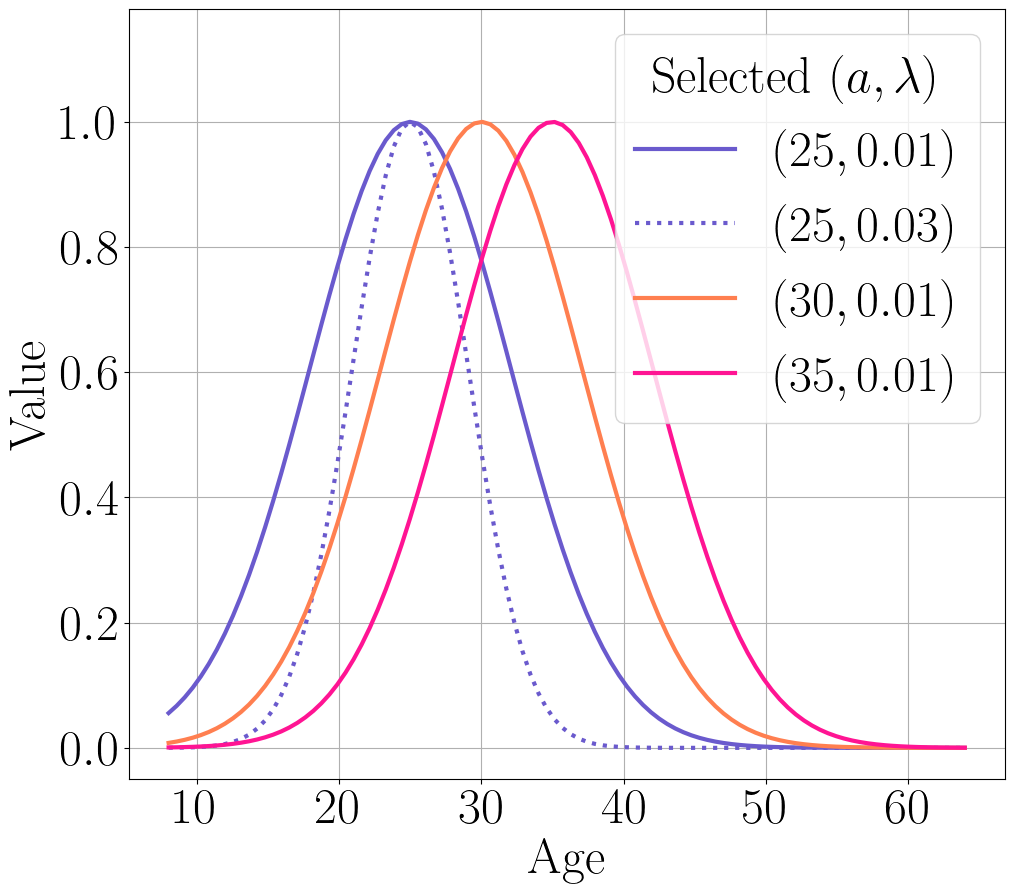

In [14]:
x = np.linspace(8,64,100)

basis_functions_set = [gauss_kernel(x,parameters[ss][0],parameters[ss][1]) for ss in s]
text = ['$(25, 0.01)$', '$(25, 0.03)$', '$(30, 0.01)$', '$(30, 0.03)$', '$(35, 0.01)$', '$(35, 0.03)$']
color = ['slateblue','slateblue','coral','coral','deeppink','deeppink']
linestyle = ['-',':','-',':','-',':']

fig,ax = plt.subplots(figsize=(11.3,10))
for ss in s:
    ax.plot(x, gauss_kernel(x,parameters[ss][0],parameters[ss][1]), 
    color = color[ss], linewidth = 3,linestyle=linestyle[ss], label = text[ss])

sz = 36
ax.set_xlabel('Age', size = sz)
ax.set_ylabel('Value', size = sz)
ax.set_ylim([-0.05, 1.18])
plt.xticks(size = sz)
plt.yticks(size = sz)

rc('text', usetex=True)
rc('font', family='serif')

ax.legend(title='Selected $(a, \lambda)$', prop={'size': sz},\
         title_fontsize=sz, loc='upper right')

plt.grid()

plt.savefig(image_path+'basis.pdf')
plt.show()

Aging effect

In [15]:
age_effect = lambda t: sum([v_plusDC[i]*gauss_kernel(t,parameters[ss][0],parameters[ss][1]) for i,ss in enumerate(s)])

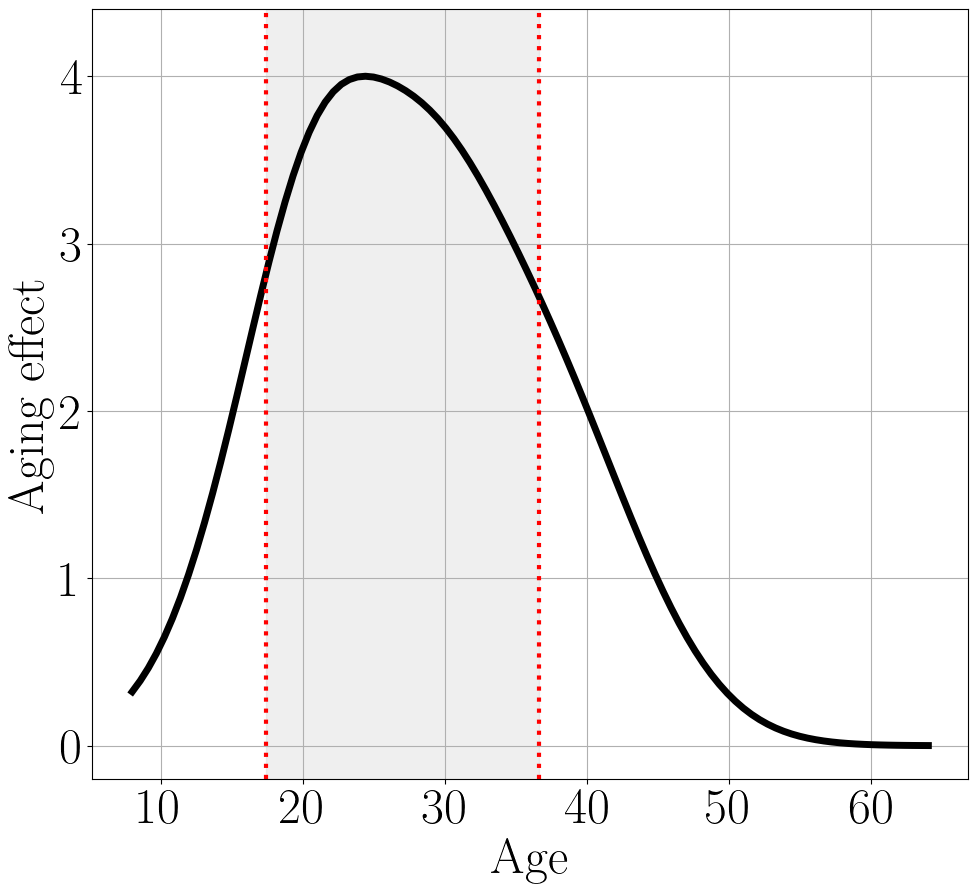

In [16]:
#plot
x = np.linspace(8,64,100)
y = age_effect(x)

fig,ax = plt.subplots(figsize=(11.3,10))
ax.plot(x, y, color = 'black', linewidth = 5)

ax.axvline(x=17.4, color='red', linestyle=':', linewidth = 3)
ax.axvline(x=36.6, color='red', linestyle=':', linewidth = 3)
ax.fill_betweenx(y*100-20, 17.4, 36.6, color='gray', alpha=0.12)

sz = 36
ax.set_xlabel('Age', size = sz)
ax.set_ylabel('Aging effect', size = sz)
ax.set_ylim([-0.2, 4.4])
plt.xticks(size = sz)
plt.yticks(size = sz)

rc('text', usetex=True)
rc('font', family='serif')
plt.grid()

plt.savefig(image_path+'age_effect.pdf')
plt.show()

Dynamic score

In [17]:
# setting
total_num = 10
players = top_player[:total_num]
players_information = {}

In [18]:
with open(data_path+'birthday.txt','r') as f:
    lines = f.readlines()[:total_num]
for line,player in zip(lines,players):
    win_age = df[df['winner_name'] == player]['winner_age']
    lose_age = df[df['loser_name'] == player]['loser_age']

    birthday = float(line[:-1].split(':')[1])
    start_year = birthday+min(min(win_age),min(lose_age),19)
    end_year = birthday+max([max(win_age),max(lose_age)])

    temp = {'birthday':birthday,
            'start_year':start_year,
            'end_year':end_year,
            }

    players_information[player] = temp
    

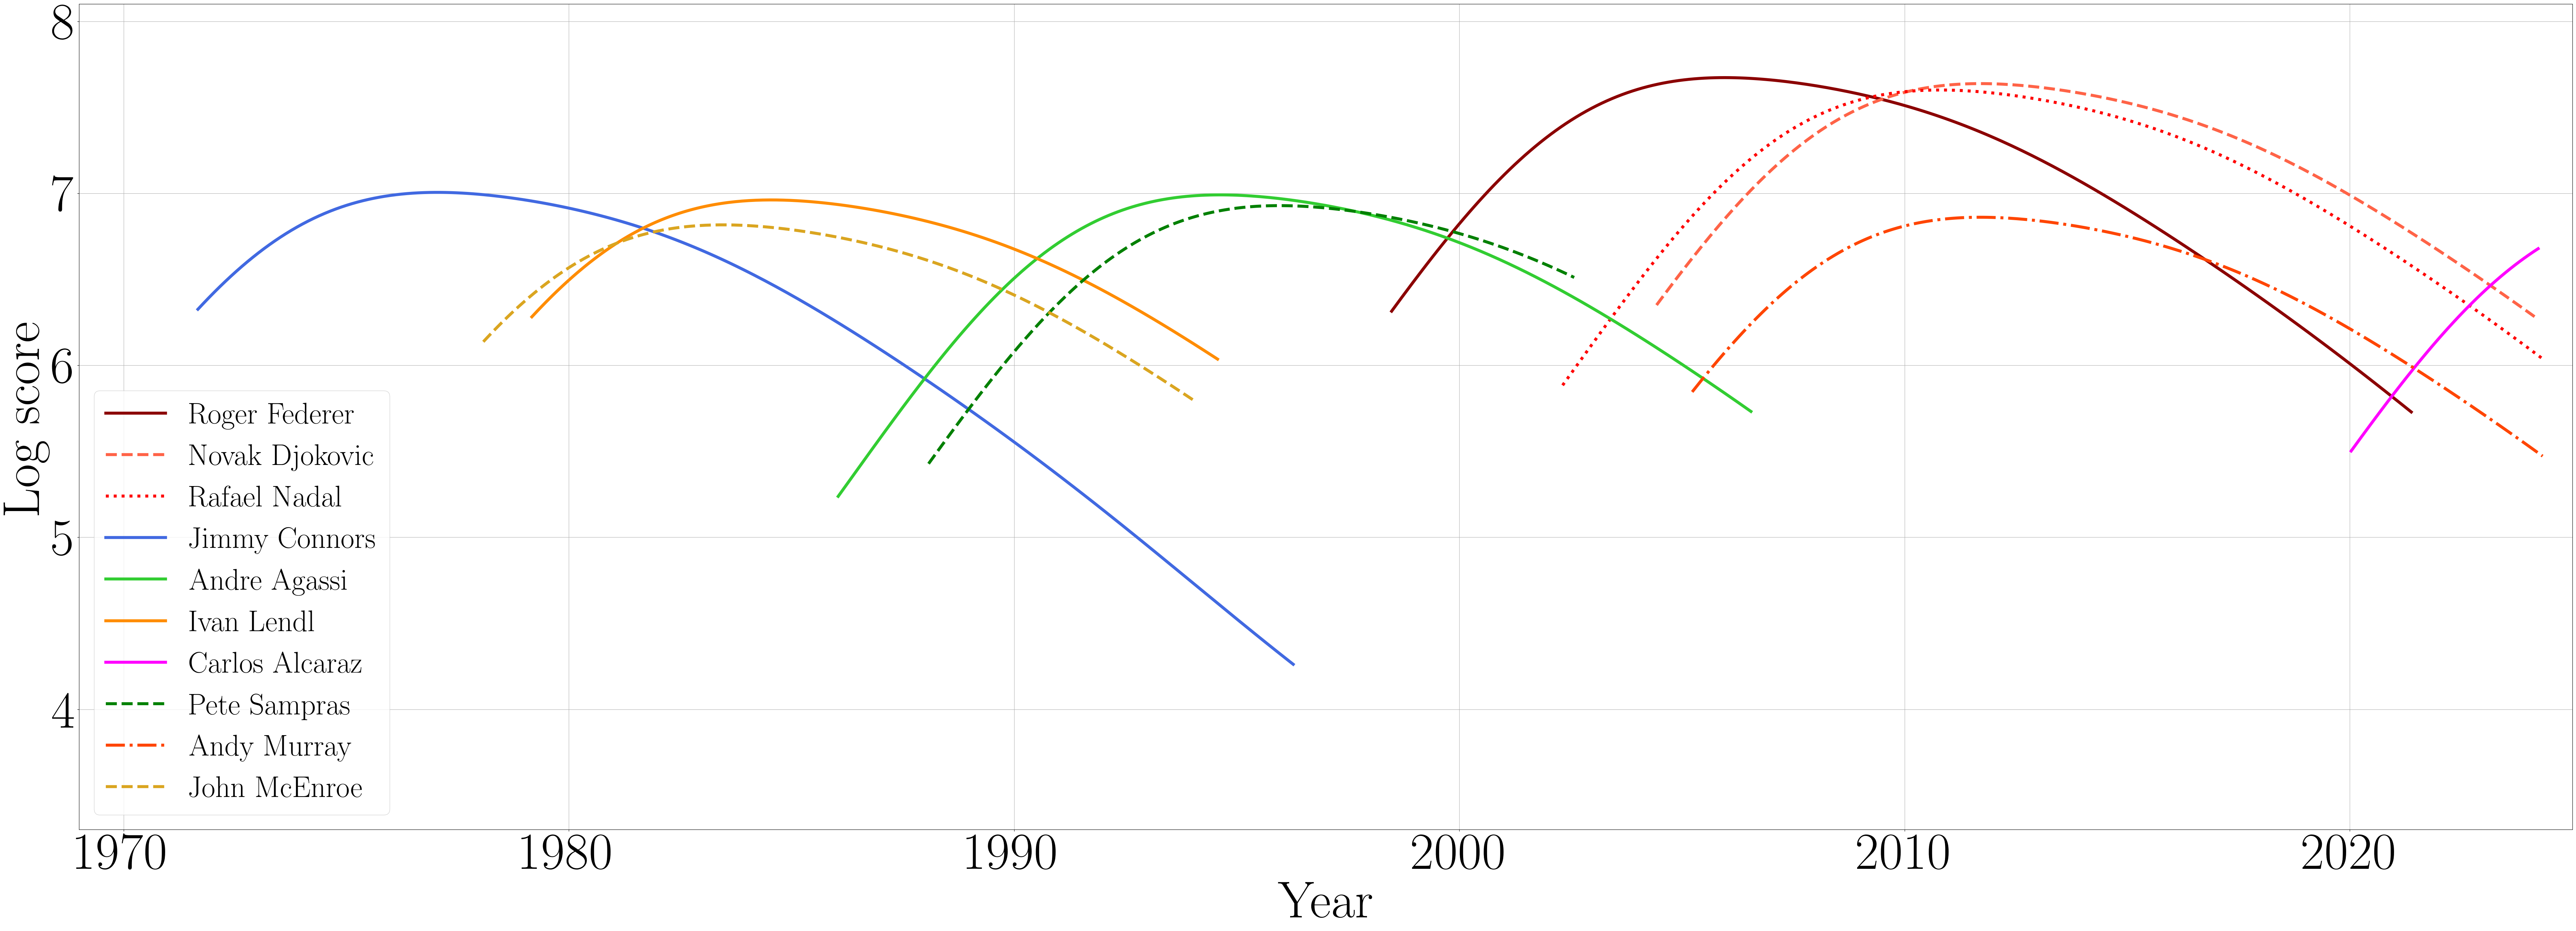

In [19]:
fig,ax = plt.subplots(figsize=(90,30))
sz = 105
ax.set_xlabel('Year', size = sz)
ax.set_ylabel('Log score', size = sz)
ax.set_ylim([3.3, 8.1])
ax.set_xlim([1969, 2025])
plt.xticks(size = sz)
plt.yticks(size = sz)
rc('text', usetex=True)
rc('font', family='serif')

year_tag = [('darkred', '-'),('tomato', '--'), ('red', ':'),\
            ('royalblue', '-'), ('limegreen', '-'), ('darkorange', '-'),\
            ('magenta', '-'), ('green', '--'), ('orangered', '-.'), \
            ('goldenrod', '--')]


for i,player in enumerate(players):

    start_year = players_information[player]['start_year']
    end_year = players_information[player]['end_year']
    birthday = players_information[player]['birthday']

    period = np.linspace(start_year, end_year, 200)
    
    u = u_plusDC[playerID[player]]
    score = age_effect(period-birthday)+u

    
    ax.plot(period,score,color = year_tag[i][0], 
            linestyle = year_tag[i][1], linewidth = 6, label = top_player[i])
ax.legend(prop={'size': 60}, title_fontsize=sz, loc = 'lower left', bbox_to_anchor=(0, 0))


plt.grid()
plt.savefig(image_path+'dynamic_score.pdf')
plt.show()